# Notebook 13 — Harmonic Conjugates: Where ∇ Meets Complex Analysis

Notebook 08 introduced $f(x,y)=x^3-3xy^2$ as an example with $\nabla^2f=0$
everywhere, mentioning in passing that it's "the real part of $z^3$" and
moving on. This notebook comes back for that thread: *why* does being the
real part of a complex-differentiable function force $\nabla^2f=0$, what's
the imaginary part doing, and what does the pair of them look like
together? The answer connects two things that seem unrelated at first —
complex analysis and gradients — through a proof that's really just
notebook 05's mixed-partials identity wearing a different notation.

In [1]:
# Make src/ importable from inside notebooks/
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
%matplotlib inline

from src import operators as ops


## 1. By hand

Write a complex function as $f(z) = u(x,y) + i\,v(x,y)$ with $z=x+iy$. If
$f$ is complex-differentiable (**holomorphic**), $u$ and $v$ can't be just
any two functions — they're locked together by the **Cauchy-Riemann
equations**:

$$\frac{\partial u}{\partial x} = \frac{\partial v}{\partial y} \qquad\qquad \frac{\partial u}{\partial y} = -\frac{\partial v}{\partial x}$$

Two consequences fall out immediately, and both are just notebook 05's
identity 1 (mixed partials commute) in disguise:

**$u$ and $v$ are both harmonic.** Differentiate the first CR equation by
$x$ and the second by $y$:

$$\frac{\partial^2 u}{\partial x^2} = \frac{\partial^2 v}{\partial y\partial x}, \qquad\qquad \frac{\partial^2 u}{\partial y^2} = -\frac{\partial^2 v}{\partial x\partial y}$$

Add them. The right-hand sides are the same mixed partial derivative of
$v$, computed in opposite orders — they cancel exactly (Clairaut's
theorem, precisely notebook 05's identity 1), leaving $\nabla^2u=0$. The
same trick starting from $v$ gives $\nabla^2v=0$. $u$ and $v$ are called
**harmonic conjugates** of each other.

**$\nabla u$ and $\nabla v$ are perpendicular everywhere.** Using the CR
equations to rewrite $\nabla v = (\partial v/\partial x,\ \partial
v/\partial y) = (-\partial u/\partial y,\ \partial u/\partial x)$:

$$\nabla u\cdot\nabla v = \frac{\partial u}{\partial x}\left(-\frac{\partial u}{\partial y}\right) + \frac{\partial u}{\partial y}\frac{\partial u}{\partial x} = 0$$

Geometrically: the level curves of $u$ and the level curves of $v$ cross
at right angles everywhere, forming two interlocking orthogonal families —
section 4 renders exactly this picture.

**Worked example.** $f(z) = z^3 = (x+iy)^3 = (x^3-3xy^2) + i(3x^2y-y^3)$,
so $u = x^3-3xy^2$ (notebook 08's example) and $v = 3x^2y-y^3$. Check CR:

- $\partial u/\partial x = 3x^2-3y^2$, and $\partial v/\partial y = 3x^2-3y^2$ — match.
- $\partial u/\partial y = -6xy$, and $-\partial v/\partial x = -6xy$ — match.

So this $u,v$ pair really is a harmonic-conjugate pair, and notebook 08's
$\nabla^2u=0$ wasn't a one-off — it was guaranteed the moment $u$ was
written down as $\text{Re}(z^3)$.

## 2. SymPy verification

In [2]:
x, y = sp.symbols('x y')

u_sym = x**3 - 3 * x * y**2
v_sym = 3 * x**2 * y - y**3

cr1 = sp.simplify(sp.diff(u_sym, x) - sp.diff(v_sym, y))
cr2 = sp.simplify(sp.diff(u_sym, y) + sp.diff(v_sym, x))
print("∂u/∂x − ∂v/∂y =", cr1)
print("∂u/∂y + ∂v/∂x =", cr2)

lap_u = sp.simplify(sp.diff(u_sym, x, 2) + sp.diff(u_sym, y, 2))
lap_v = sp.simplify(sp.diff(v_sym, x, 2) + sp.diff(v_sym, y, 2))
print("∇²u =", lap_u, " ∇²v =", lap_v)

grad_dot = sp.simplify(sp.diff(u_sym, x) * sp.diff(v_sym, x) + sp.diff(u_sym, y) * sp.diff(v_sym, y))
print("∇u · ∇v =", grad_dot)


∂u/∂x − ∂v/∂y = 0
∂u/∂y + ∂v/∂x = 0
∇²u = 0  ∇²v = 0
∇u · ∇v = 0


## 3. NumPy on a grid

In [3]:
x_vals = np.linspace(-2, 2, 200)
y_vals = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x_vals, y_vals)
dx = x_vals[1] - x_vals[0]
dy = y_vals[1] - y_vals[0]

u = X**3 - 3 * X * Y**2
v = 3 * X**2 * Y - Y**3

lap_u = ops.laplacian_2d(u, dx, dy)
lap_v = ops.laplacian_2d(v, dx, dy)
du_dx, du_dy = ops.gradient_2d(u, dx, dy)
dv_dx, dv_dy = ops.gradient_2d(v, dx, dy)
dot = du_dx * dv_dx + du_dy * dv_dy

interior = slice(3, -3)
print(f"max |∇²u| = {np.max(np.abs(lap_u[interior, interior])):.2e}")
print(f"max |∇²v| = {np.max(np.abs(lap_v[interior, interior])):.2e}")
print(f"max |∇u · ∇v| = {np.max(np.abs(dot[interior, interior])):.2e}")


max |∇²u| = 1.53e-11
max |∇²v| = 1.54e-11
max |∇u · ∇v| = 1.82e-02


The two Laplacians land at machine precision — the same
$D_xD_y=D_yD_x$ operator-commuting phenomenon notebook 05 found, since
`laplacian_2d` composes central-difference stencils on a single field. The
orthogonality check does **not** land at machine precision, and
shouldn't: $\nabla u\cdot\nabla v$ multiplies together two *independently*
finite-differenced fields rather than composing operators on one field, so
there's no algebraic cancellation forcing it to vanish exactly in floating
point — it only holds up to ordinary truncation error, the same `O(Δx^2)`
story as notebook 06. A quick check confirms that's really what's
happening rather than a bug:

In [4]:
resolutions = np.array([50, 100, 200, 400, 800])
dot_errors = []

for n in resolutions:
    xv = np.linspace(-2, 2, n)
    yv = np.linspace(-2, 2, n)
    Xr, Yr = np.meshgrid(xv, yv)
    dxr, dyr = xv[1] - xv[0], yv[1] - yv[0]
    ur = Xr**3 - 3 * Xr * Yr**2
    vr = 3 * Xr**2 * Yr - Yr**3
    duxr, duyr = ops.gradient_2d(ur, dxr, dyr)
    dvxr, dvyr = ops.gradient_2d(vr, dxr, dyr)
    dot_r = duxr * dvxr + duyr * dvyr
    dot_errors.append(np.max(np.abs(dot_r[3:-3, 3:-3])))

dot_errors = np.array(dot_errors)
order = np.polyfit(np.log(1 / resolutions), np.log(dot_errors), 1)[0]
print(f"empirical convergence order of ∇u·∇v = {order:.2f}   (matches notebook 06's O(Δx²) central differences)")


empirical convergence order of ∇u·∇v = 1.93   (matches notebook 06's O(Δx²) central differences)


## 4. Visualization

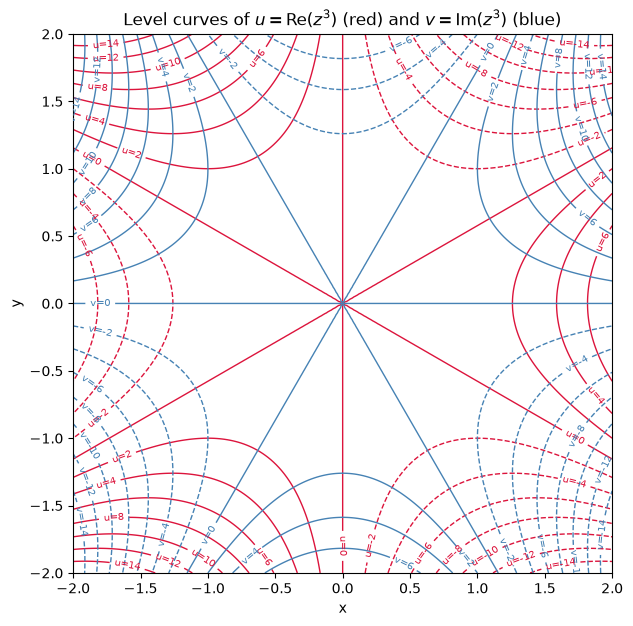

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))

cu = ax.contour(X, Y, u, levels=15, colors="crimson", linewidths=1.0)
cv = ax.contour(X, Y, v, levels=15, colors="steelblue", linewidths=1.0)
ax.clabel(cu, inline=True, fontsize=7, fmt="u=%.0f")
ax.clabel(cv, inline=True, fontsize=7, fmt="v=%.0f")

ax.set_title(r"Level curves of $u=\mathrm{Re}(z^3)$ (red) and $v=\mathrm{Im}(z^3)$ (blue)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_aspect("equal")
plt.show()


**Reading this.** Every red curve crosses every blue curve at a right
angle, everywhere they meet — that's $\nabla u\cdot\nabla v=0$ made
visible, not asserted. Each family is also a legitimate way to slice up
the plane on its own (level curves of *any* smooth function tile the plane
without crossing themselves), but together they form a curved analogue of
ordinary graph paper: two orthogonal coordinate grids, bent to follow
$z^3$.

**A forward pointer.** Notebook 10 split a general vector field into a
gradient part $\nabla\phi$ and a stream-function part described by $\psi$,
using two potentials that were, in general, unrelated to each other. A
field that's *both* irrotational ($\nabla\times F=0$) *and*
divergence-free ($\nabla\cdot F=0$) — the classical setup for 2D
incompressible, non-swirling fluid flow — is the special case where $\phi$
and $\psi$ stop being independent and become a harmonic-conjugate pair
exactly like $u,v$ here. That's why complex analysis (not just vector
calculus) is the standard toolkit for 2D potential flow: $w(z)=\phi+i\psi$
packages both potentials into one holomorphic function, and everything in
section 1 applies to it for free.

## 5. Exercise

Do the same three checks — Cauchy-Riemann, both Laplacians, gradient
orthogonality — for $f(z) = e^z$, i.e. $u=e^x\cos y$, $v=e^x\sin y$ (the
identity $e^{x+iy}=e^x(\cos y + i\sin y)$ gives this split directly). Then
render the same style of orthogonal-contour plot as section 4. The shapes
will look nothing like $z^3$'s — concentric-ish rays and circles rather
than hyperbola-like curves — but the right-angle crossing property should
hold just as exactly.


In [6]:
# Your answer here.
# u_exp = np.exp(X) * np.cos(Y)
# v_exp = np.exp(X) * np.sin(Y)
# ...
